# Comparativa

En este notebook se realiza un análisis comparativo de los modelos de forecasting aplicados a la serie de cortes semanales. Los resultados —métricas de error y predicciones— son leídos directamente desde la carpeta resultados_modelos, donde cada modelo tiene su propio archivo de métricas (metrics_<modelo>.csv) y predicciones (predictions_<modelo>.csv), generados previamente en los scripts individuales de cada enfoque. A partir de estos archivos se construye una evaluación en dos dimensiones: por un lado, las métricas clásicas de error (RMSE y MAE) que permiten un ranking general de precisión; por otro, un conjunto de métricas orientadas al uso operativo de las predicciones, dado que el objetivo no es solo minimizar el error promedio sino anticipar correctamente semanas de alta demanda. Para esto se evalúan la variabilidad de las predicciones, la exactitud direccional, el sesgo sistemático y la capacidad de detección de picos, entendiendo como pico toda semana cuyo valor real supere el percentil 75 de la serie en el período de evaluación.

## Librerías

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob, os

pd.set_option('display.float_format', '{:.4f}'.format)


## Lectura de métricas

In [4]:
metrics_files = glob.glob("resultados_modelos/metrics_*.csv")

dfs = []
for f in metrics_files:
    dfs.append(pd.read_csv(f))

metrics = pd.concat(dfs, ignore_index=True)
# normalizar columnas (AutoML tiene extras)
metrics = metrics[['model', 'serie', 'rmse', 'mae']]
metrics

,model,serie,rmse,mae
0,AutoML_Uni,Cortes,8.3261,5.9961
1,AutoML_Uni,Temp,2.6153,2.0009
2,AutoML_Uni,Hum,7.2775,5.6944
3,AutoML_Multi,Cortes (Temp+Hum),7.9112,5.9163
4,exp_smoothing,Cortes,9.5747,7.3958
5,exp_smoothing,Temp,2.7474,2.1755
6,exp_smoothing,Hum,8.2438,6.6796
7,fft,Cortes,8.1111,6.1685
8,fft,Temp,2.6426,2.1524
9,fft,Hum,7.7602,5.7886


In [5]:
SERIE = 'Cortes'   # ← cambiar: 'Cortes', 'Temp', 'Hum'

tabla = (
    metrics[metrics['serie'].str.contains(SERIE)]
    .sort_values('rmse')
    .reset_index(drop=True)
)
tabla.index += 1
tabla.style.background_gradient(subset=['rmse','mae'], cmap='RdYlGn_r')

,model,serie,rmse,mae
1,transformer_uni,Cortes,7.910586,5.857847
2,AutoML_Multi,Cortes (Temp+Hum),7.911200,5.916300
3,LSTM_Uni,Cortes,7.929800,5.728500
4,SVR_Uni,Cortes,7.981000,5.493700
5,transformer_multi,Cortes,8.070095,6.217362
6,fft,Cortes,8.111080,6.168456
7,LSTM_Multi,Cortes (Temp+Hum),8.136700,6.164900
8,AutoML_Uni,Cortes,8.326100,5.996100
9,Prophet,Cortes,8.550400,6.776200
10,SVR_Multi,Cortes (Temp+Hum),8.599300,5.662000


La tabla presenta el ranking de modelos ordenado por RMSE sobre el conjunto de test (20% final de la serie). A primera vista, los modelos con menor error son transformer_uni, AutoML_Multi y LSTM_Uni, mientras que exp_smoothing queda último. 

In [6]:
pred_files = glob.glob("resultados_modelos/predictions_*.csv")

dfs = []
for f in pred_files:
    dfs.append(pd.read_csv(f, parse_dates=['date']))

preds = pd.concat(dfs, ignore_index=True)


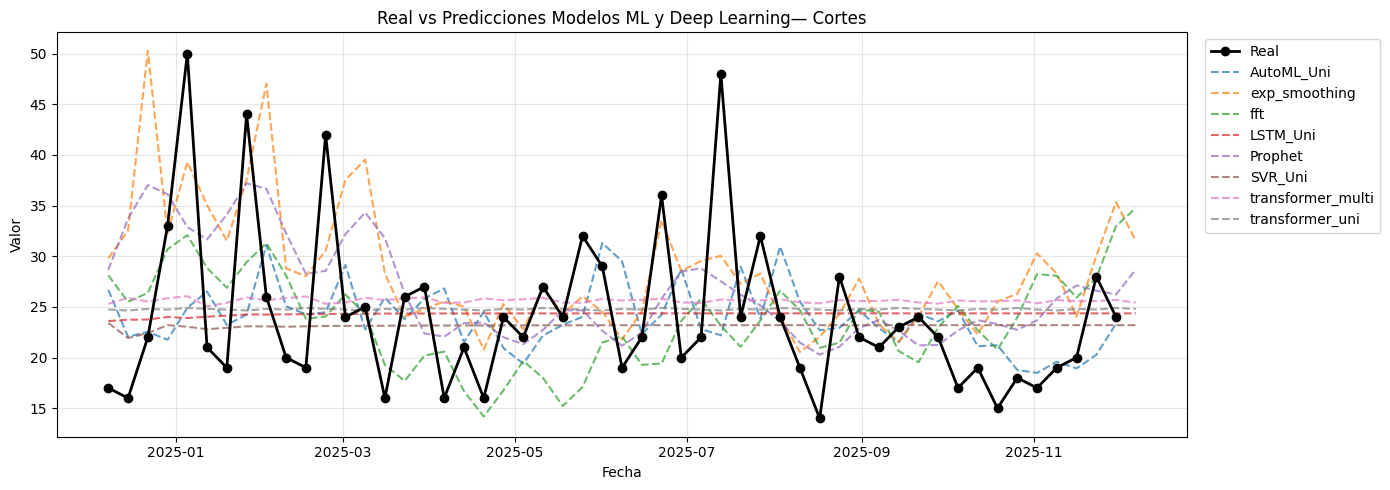

In [7]:
SERIE = 'Cortes'

subset = preds[preds['serie'] == SERIE].copy()
models_in_serie = subset['model'].unique()

fig, ax = plt.subplots(figsize=(14, 5))

# serie real (igual en todos, tomamos del primero)
real = subset[subset['model'] == models_in_serie[0]].sort_values('date')
ax.plot(real['date'], real['y_true'], 'k-o', lw=2, label='Real', zorder=10)

# predicciones por modelo
for model in models_in_serie:
    df_m = subset[subset['model'] == model].sort_values('date')
    ax.plot(df_m['date'], df_m['y_pred'], '--', label=model, alpha=0.7)

ax.set_title(f'Real vs Predicciones Modelos ML y Deep Learning— {SERIE}')
ax.set_xlabel('Fecha')
ax.set_ylabel('Valor')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Los modelos "planos" (LSTM, SVR, Transformers) están prediciendo cerca de la media (~24). Eso es operativamente inútil — te dice "va a haber cortes promedio" siempre, pero nunca te avisa de picos ni valles.

Su RMSE bajo es engañoso: minimizaron el error siendo conservadores.

## Métricas adicionales

In [8]:
dfs = []
for f in glob.glob("resultados_modelos/predictions_*.csv"):
    dfs.append(pd.read_csv(f, parse_dates=['date']))
preds = pd.concat(dfs, ignore_index=True)

# quedarse solo con predicciones de Cortes (uni y multi)
cortes = preds[preds['serie'].str.contains('Cortes')].copy()

# ── umbral para picos (percentil 75 del y_true del test) ────────────
umbral = cortes['y_true'].quantile(0.75)
print(f"Umbral picos (p75): {umbral:.1f} cortes")



Umbral picos (p75): 27.0 cortes


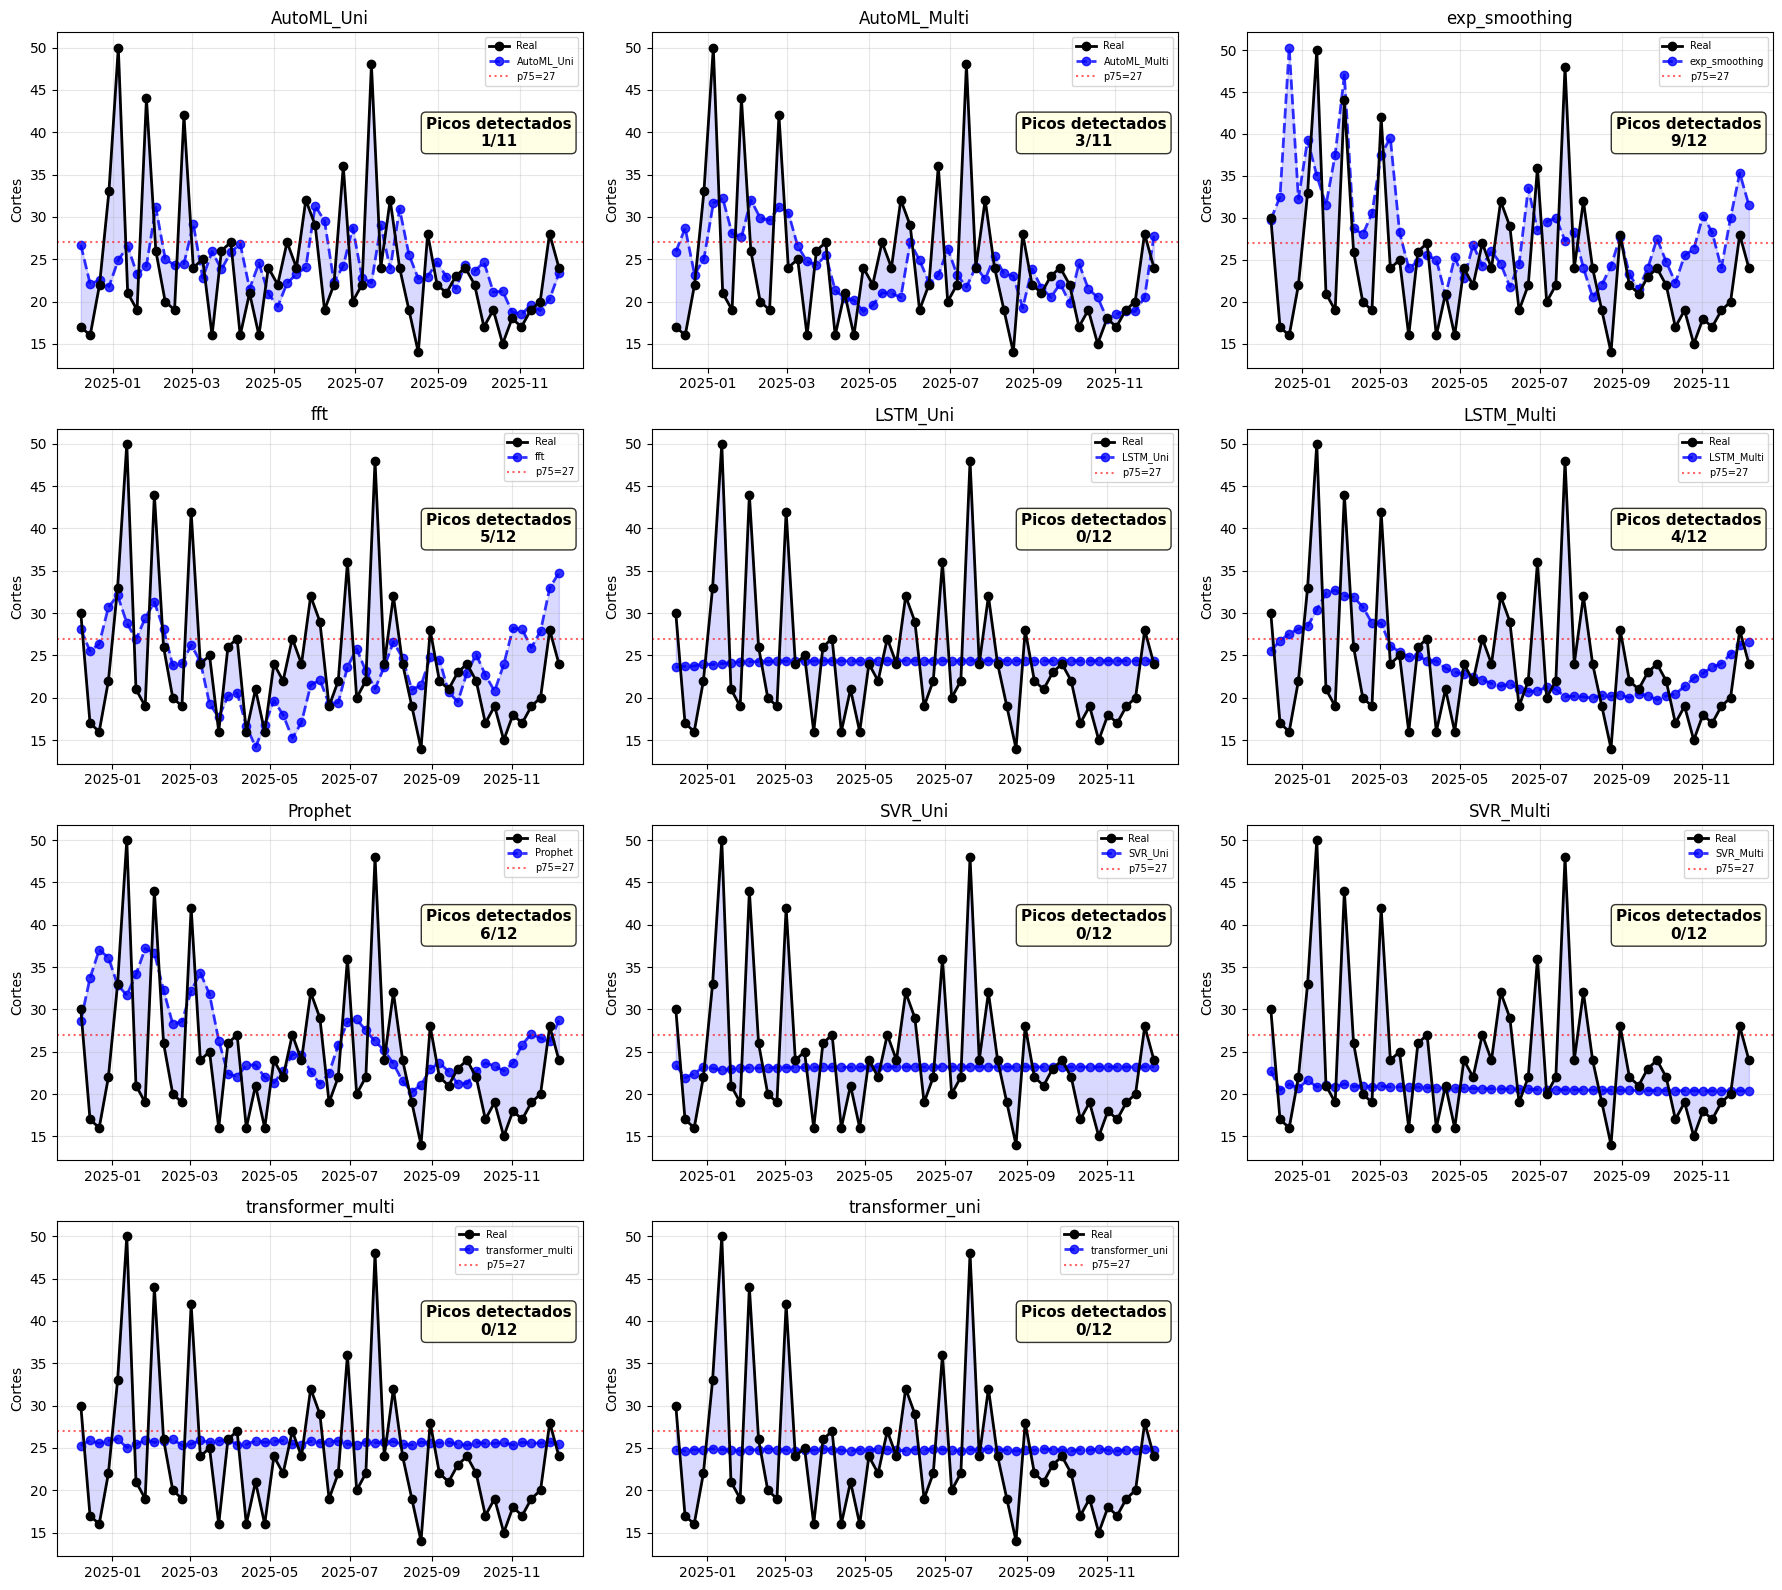

In [9]:
modelos = cortes['model'].unique()
ncols = 3
nrows = int(np.ceil(len(modelos) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows))
axes = axes.flatten()

for i, model in enumerate(modelos):
    ax = axes[i]
    df_m = cortes[cortes['model'] == model].sort_values('date')
    
    mask_picos = df_m['y_true'] > umbral
    picos_total = mask_picos.sum()
    picos_detectados = (df_m['y_pred'][mask_picos] > umbral).sum()
    
    ax.plot(df_m['date'], df_m['y_true'], 'k-o', lw=2, label='Real', zorder=10)
    ax.plot(df_m['date'], df_m['y_pred'], 'b--o', lw=2, label=model, alpha=0.8)
    ax.fill_between(df_m['date'], df_m['y_true'], df_m['y_pred'], alpha=0.15, color='blue')
    ax.axhline(umbral, color='red', linestyle=':', alpha=0.6, label=f'p75={umbral:.0f}')
    
    ax.text(0.84, 0.7,
            f'Picos detectados\n{picos_detectados}/{picos_total}',
            transform=ax.transAxes,
            fontsize=11, fontweight='bold',
            ha='center', va='center',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    
    ax.set_title(model)
    ax.set_ylabel('Cortes')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

# ocultar subplots vacíos
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


In [10]:
# ── métricas por modelo ──────────────────────────────────────────────
resultados = []

for model, df in cortes.groupby('model'):
    df = df.sort_values('date').reset_index(drop=True)
    
    y_true = df['y_true']
    y_pred = df['y_pred']
    
    # 1. var_ratio
    var_ratio = y_pred.std() / y_true.std()
    
    # 2. directional accuracy
    dy_true = y_true.diff().dropna()
    dy_pred = y_pred.diff().dropna()
    dir_acc = (np.sign(dy_true.values) == np.sign(dy_pred.values)).mean()
    
    # 3. bias
    bias = (y_pred - y_true).mean()
    
    # 4. peak_recall
    mask_picos = y_true > umbral
    if mask_picos.sum() > 0:
        peak_recall = (y_pred[mask_picos] > umbral).mean()
    else:
        peak_recall = np.nan

    resultados.append({
        'model': model,
        'var_ratio': round(var_ratio, 3),
        'dir_acc':   round(dir_acc, 3),
        'bias':      round(bias, 3),
        'peak_recall': round(peak_recall, 3)
    })

resultado_df = pd.DataFrame(resultados).sort_values('dir_acc', ascending=False).reset_index(drop=True)
resultado_df

,model,var_ratio,dir_acc,bias,peak_recall
0,fft,0.5820,0.5960,-0.5250,0.4170
1,SVR_Multi,0.0490,0.5580,-3.5770,0.0000
2,transformer_uni,0.0100,0.5580,0.5260,0.0000
3,exp_smoothing,0.7740,0.5190,4.3440,0.7500
4,SVR_Uni,0.0270,0.4620,-1.1170,0.0000
5,LSTM_Multi,0.4790,0.4620,-0.2420,0.3330
6,AutoML_Multi,0.4880,0.4510,-0.2510,0.2730
7,AutoML_Uni,0.3890,0.4510,-0.1640,0.0910
8,transformer_multi,0.0270,0.4420,1.3730,0.0000
9,LSTM_Uni,0.0220,0.4040,0.0420,0.0000


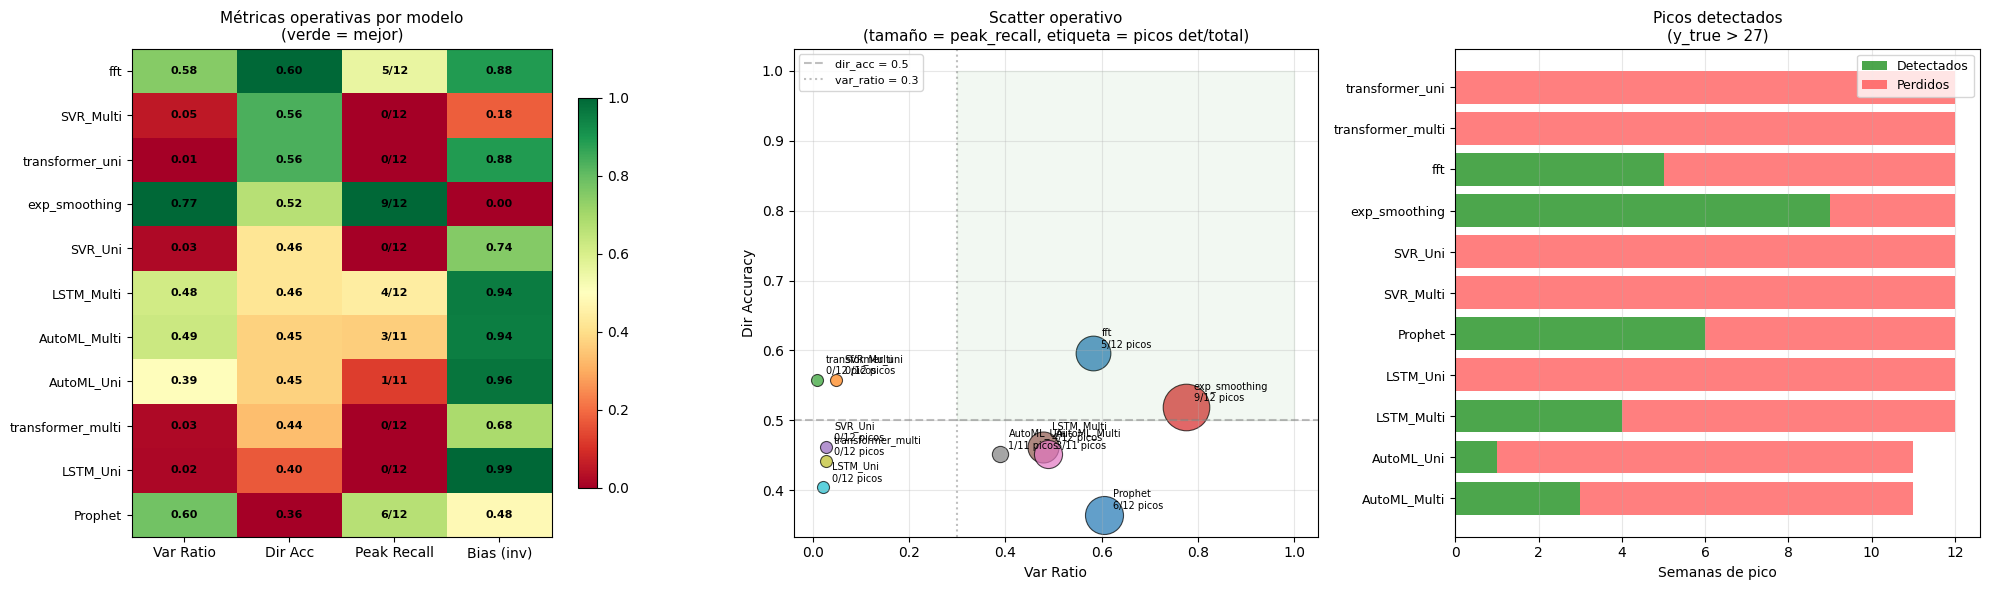

In [11]:
import matplotlib.pyplot as plt
import numpy as np

df = resultado_df.set_index('model')

# picos por modelo
picos_info = {}
for model, grp in cortes.groupby('model'):
    grp = grp.sort_values('date')
    mask = grp['y_true'] > umbral
    total = mask.sum()
    detectados = (grp['y_pred'][mask] > umbral).sum()
    picos_info[model] = (int(detectados), int(total))

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# ── 1. Heatmap ───────────────────────────────────────────────────────
ax = axes[0]

heat = df[['var_ratio', 'dir_acc', 'peak_recall']].copy()
heat['bias_abs'] = 1 - (df['bias'].abs() / df['bias'].abs().max())
cols_heat = ['var_ratio', 'dir_acc', 'peak_recall', 'bias_abs']
labels_heat = ['Var Ratio', 'Dir Acc', 'Peak Recall', 'Bias (inv)']

heat_norm = (heat[cols_heat] - heat[cols_heat].min()) / (heat[cols_heat].max() - heat[cols_heat].min())

im = ax.imshow(heat_norm.values, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
ax.set_xticks(range(len(labels_heat)))
ax.set_xticklabels(labels_heat, fontsize=10)
ax.set_yticks(range(len(heat_norm)))
ax.set_yticklabels(heat_norm.index, fontsize=9)

for i, model in enumerate(heat_norm.index):
    for j, col in enumerate(cols_heat):
        val = heat[col].iloc[i]
        # en peak_recall mostrar X/Y
        if col == 'peak_recall' and model in picos_info:
            det, tot = picos_info[model]
            label = f'{det}/{tot}'
        else:
            label = f'{val:.2f}'
        ax.text(j, i, label, ha='center', va='center', fontsize=8, fontweight='bold')

ax.set_title('Métricas operativas por modelo\n(verde = mejor)', fontsize=11)
plt.colorbar(im, ax=ax, shrink=0.8)

# ── 2. Scatter ───────────────────────────────────────────────────────
ax2 = axes[1]

for model, row in df.iterrows():
    size = max(row['peak_recall'], 0.05) * 1500
    ax2.scatter(row['var_ratio'], row['dir_acc'], s=size, alpha=0.7,
                edgecolors='black', linewidths=0.8)
    det, tot = picos_info.get(model, (0, 0))
    ax2.annotate(f'{model}\n{det}/{tot} picos',
                 (row['var_ratio'], row['dir_acc']),
                 textcoords='offset points', xytext=(6, 4), fontsize=7)

ax2.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='dir_acc = 0.5')
ax2.axvline(0.3, color='gray', linestyle=':', alpha=0.5, label='var_ratio = 0.3')
ax2.fill_between([0.3, 1.0], 0.5, 1.0, alpha=0.05, color='green')
ax2.set_xlabel('Var Ratio', fontsize=10)
ax2.set_ylabel('Dir Accuracy', fontsize=10)
ax2.set_title('Scatter operativo\n(tamaño = peak_recall, etiqueta = picos det/total)', fontsize=11)
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# ── 3. Barras picos detectados vs perdidos ───────────────────────────
ax3 = axes[2]

modelos_list = list(picos_info.keys())
detectados_list = [picos_info[m][0] for m in modelos_list]
perdidos_list   = [picos_info[m][1] - picos_info[m][0] for m in modelos_list]

y_pos = np.arange(len(modelos_list))
ax3.barh(y_pos, detectados_list, color='green', alpha=0.7, label='Detectados')
ax3.barh(y_pos, perdidos_list, left=detectados_list, color='red', alpha=0.5, label='Perdidos')

ax3.set_yticks(y_pos)
ax3.set_yticklabels(modelos_list, fontsize=9)
ax3.set_xlabel('Semanas de pico')
ax3.set_title(f'Picos detectados\n(y_true > {umbral:.0f})', fontsize=11)
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()


Los dos modelos más  útiles operativamente

FFT: el más equilibrado — dir_acc=0.60 (el mejor), 5/12 picos, bias casi nulo. Es el único en la zona ideal del scatter.
Exp Smoothing: el mejor detector de picos (9/12), pero su bias_inv=0.00 confirma que sobreestima siempre ~4 cortes. Útil para alarma temprana, no para estimar magnitud.

## Modelos clásicos vs ML

In [13]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX


In [14]:
# ── cargar serie original ────────────────────────────────────────────
df_orig = pd.read_csv("completo.csv", 
                       parse_dates=['Semana'], 
                       index_col='Semana',
                       decimal=',')
df_orig.index.freq = 'W'

# mismo corte 80/20
train_size = int(len(df_orig) * 0.8)
y_train = df_orig['Cortes'].iloc[:train_size]
y_test  = df_orig['Cortes'].iloc[train_size:]

# ── fitear modelo ganador del TP1 ────────────────────────────────────
model = SARIMAX(
    y_train,
    order=(1, 0, 3),
    seasonal_order=(0, 0, 2, 52),
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

fc = model.get_forecast(steps=len(y_test)).predicted_mean
fc.index = y_test.index

C:\Users\Natalia\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


In [15]:
# ── armar dataframe con mismo formato que predictions_*.csv ─────────
sarima_pred = pd.DataFrame({
    'model': 'SARIMA(1,0,3)x(0,0,2)[52]',
    'serie': 'Cortes',
    'date':  y_test.index,
    'y_true': y_test.values,
    'y_pred': fc.values
})

# ── agregar al df de predicciones ya cargado ─────────────────────────
cortes_completo = pd.concat([cortes, sarima_pred], ignore_index=True)

SARIMA(1,0,3)x(0,0,2)[52]
  RMSE=7.80  MAE=6.04
  Bias=1.26
  VarRatio=0.08
  DirAcc=0.60
  PeakRecall=0.08
═══════════════════════════════════════════════════════
exp_smoothing
  RMSE=9.57  MAE=7.40
  Bias=4.34
  VarRatio=0.77
  DirAcc=0.52
  PeakRecall=0.75
═══════════════════════════════════════════════════════
fft
  RMSE=8.11  MAE=6.17
  Bias=-0.53
  VarRatio=0.58
  DirAcc=0.60
  PeakRecall=0.42
═══════════════════════════════════════════════════════


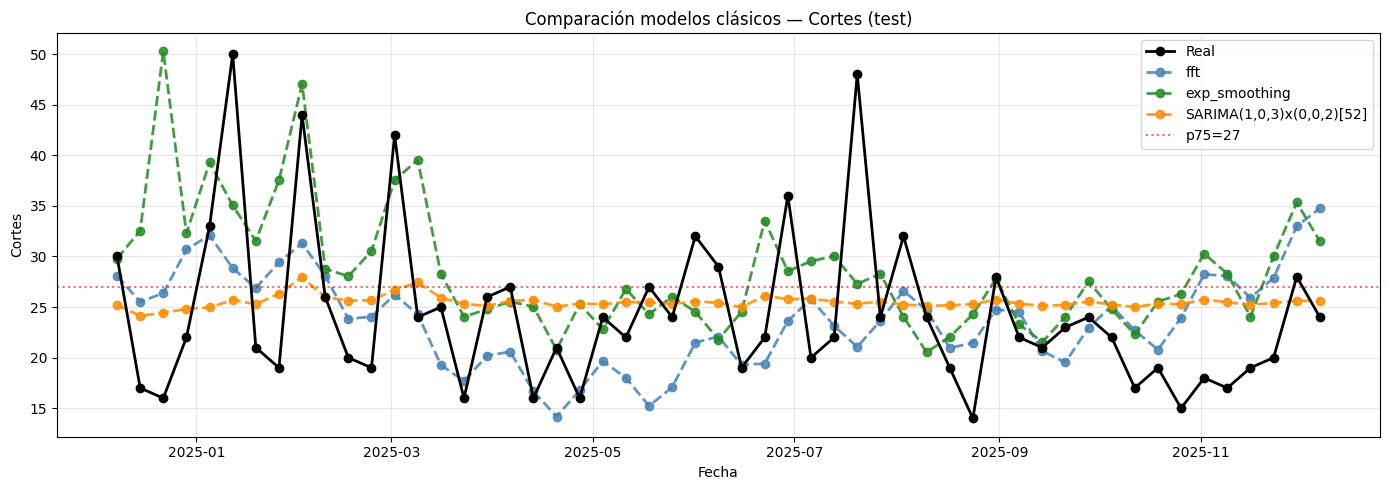

In [16]:
# ── modelos a comparar ───────────────────────────────────────
modelos_cmp = [
    'fft',
    'exp_smoothing',
    'SARIMA(1,0,3)x(0,0,2)[52]'
]

subset = cortes_completo[cortes_completo['model'].isin(modelos_cmp)].copy()

# ── métricas ─────────────────────────────────────────────────────────
for model, grp in subset.groupby('model'):
    grp = grp.sort_values('date')

    rmse = np.sqrt(((grp['y_true'] - grp['y_pred'])**2).mean())
    mae  = (grp['y_true'] - grp['y_pred']).abs().mean()
    bias = (grp['y_pred'] - grp['y_true']).mean()

    var_ratio = grp['y_pred'].std() / grp['y_true'].std()

    dy_true = grp['y_true'].diff().dropna()
    dy_pred = grp['y_pred'].diff().dropna()
    dir_acc = (np.sign(dy_true.values) == np.sign(dy_pred.values)).mean()

    mask = grp['y_true'] > umbral
    peak_recall = (grp['y_pred'][mask] > umbral).mean() if mask.sum() > 0 else np.nan

    print(f"{model}")
    print(f"  RMSE={rmse:.2f}  MAE={mae:.2f}")
    print(f"  Bias={bias:.2f}")
    print(f"  VarRatio={var_ratio:.2f}")
    print(f"  DirAcc={dir_acc:.2f}")
    print(f"  PeakRecall={peak_recall:.2f}")
    print("═" * 55)

# ── plot ─────────────────────────────────────────────────────────────
colors = {
    'fft': 'steelblue',
    'exp_smoothing': 'forestgreen',
    'SARIMA(1,0,3)x(0,0,2)[52]': 'darkorange'
}

fig, ax = plt.subplots(figsize=(14, 5))

# serie real
real = subset[subset['model'] == 'fft'].sort_values('date')
ax.plot(real['date'], real['y_true'], 'k-o', lw=2, label='Real', zorder=10)

# modelos
for model in modelos_cmp:
    grp = subset[subset['model'] == model].sort_values('date')
    ax.plot(grp['date'], grp['y_pred'], '--o',
            lw=2, color=colors[model],
            label=model, alpha=0.85)

ax.axhline(umbral, color='red', linestyle=':',
           alpha=0.6, label=f'p75={umbral:.0f}')

ax.set_title('Comparación modelos clásicos — Cortes (test)')
ax.set_xlabel('Fecha')
ax.set_ylabel('Cortes')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Pronósticos de Cortes

C:\Users\Natalia\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


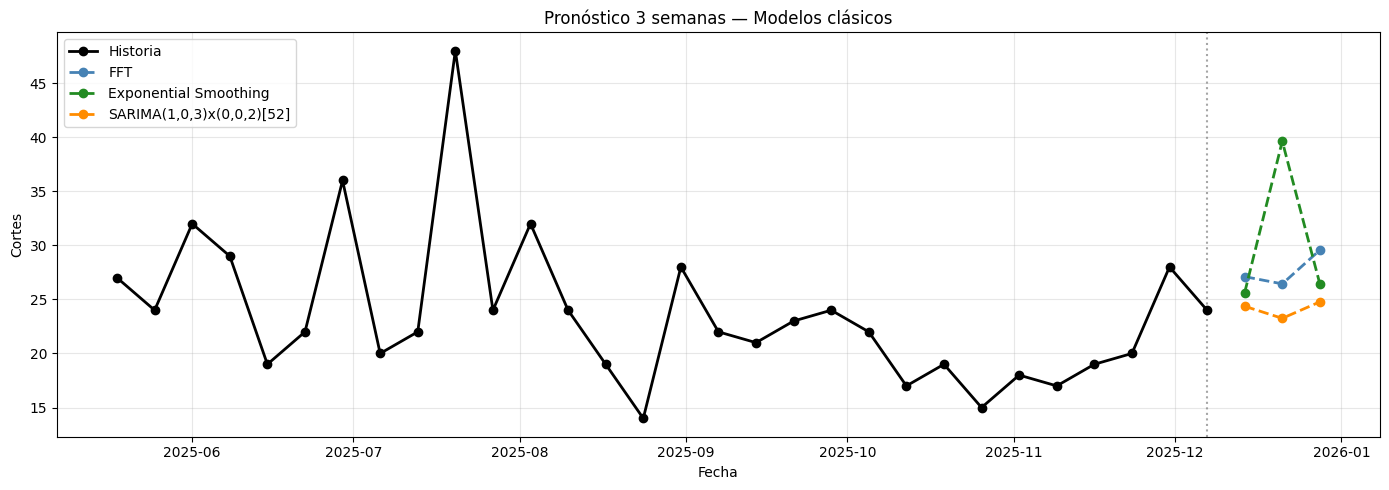

    semana     FFT  Exp_Smoothing  SARIMA
2025-12-14 27.1000        25.6000 24.4000
2025-12-21 26.4000        39.6000 23.3000
2025-12-28 29.6000        26.4000 24.8000

Concordancia entre modelos:
FFT vs SARIMA
  Correlación: 0.84
  Concordancia direccional: 1.00
----------------------------------------
EXP vs SARIMA
  Correlación: -0.95
  Concordancia direccional: 0.00
----------------------------------------
FFT vs EXP
  Correlación: -0.63
  Concordancia direccional: 0.00
----------------------------------------


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from darts import TimeSeries
from darts.models import FFT, ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

H = 3  # semanas a pronosticar

# ── serie completa ───────────────────────────────────────────
df_orig = pd.read_csv(
    "completo.csv",
    parse_dates=['Semana'],
    index_col='Semana',
    decimal=','
)

df_orig.index.freq = 'W'
serie_completa = df_orig['Cortes'].dropna()

ts_full = TimeSeries.from_series(serie_completa)

# =============================================================
# 1️⃣ FFT
# =============================================================
fft_model = FFT()
fft_model.fit(ts_full)
fft_fc = fft_model.predict(H)

fft_vals = fft_fc.values().flatten()

# Banda aproximada usando residuos históricos
fft_hist_pred = fft_model.predict(len(ts_full))
residuals_fft = ts_full - fft_hist_pred
std_fft = residuals_fft.values().std()

fft_lower = fft_vals - 1.96 * std_fft
fft_upper = fft_vals + 1.96 * std_fft

# =============================================================
# 2️⃣ Exponential Smoothing
# =============================================================
exp_model = ExponentialSmoothing()
exp_model.fit(ts_full)
exp_fc = exp_model.predict(H)

exp_vals = exp_fc.values().flatten()

# Banda aproximada residuos
exp_hist_pred = exp_model.predict(len(ts_full))
residuals_exp = ts_full - exp_hist_pred
std_exp = residuals_exp.values().std()

exp_lower = exp_vals - 1.96 * std_exp
exp_upper = exp_vals + 1.96 * std_exp

# =============================================================
# 3️⃣ SARIMA
# =============================================================
sarima_model = SARIMAX(
    serie_completa,
    order=(1, 0, 3),
    seasonal_order=(0, 0, 2, 52),
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

sarima_fc = sarima_model.get_forecast(steps=H)
sarima_vals = sarima_fc.predicted_mean.values
sarima_ci = sarima_fc.conf_int(alpha=0.05)

# =============================================================
# Fechas futuras
# =============================================================
future_dates = pd.date_range(
    start=serie_completa.index[-1] + pd.Timedelta(weeks=1),
    periods=H,
    freq='W'
)

# =============================================================
# 📊 PLOT
# =============================================================
fig, ax = plt.subplots(figsize=(14, 5))

# últimas 30 semanas
hist = serie_completa.iloc[-30:]
ax.plot(hist.index, hist.values, 'k-o', lw=2, label='Historia', zorder=10)

# FFT
ax.plot(future_dates, fft_vals, 'o--', color='steelblue', lw=2, label='FFT')
#ax.fill_between(future_dates, fft_lower, fft_upper,
 #               color='steelblue', alpha=0.15)

# Exponential Smoothing
ax.plot(future_dates, exp_vals, 'o--', color='forestgreen', lw=2,
        label='Exponential Smoothing')
#ax.fill_between(future_dates, exp_lower, exp_upper,
 #               color='forestgreen', alpha=0.15)

# SARIMA
ax.plot(future_dates, sarima_vals, 'o--',
        color='darkorange', lw=2,
        label='SARIMA(1,0,3)x(0,0,2)[52]')
#ax.fill_between(future_dates,
 #               sarima_ci.iloc[:, 0],
  #              sarima_ci.iloc[:, 1],
   #             color='darkorange',
    #            alpha=0.15,
     #           label='IC 95% SARIMA')

ax.axvline(serie_completa.index[-1],
           color='gray',
           linestyle=':',
           alpha=0.7)

ax.set_title(f'Pronóstico {H} semanas — Modelos clásicos')
ax.set_xlabel('Fecha')
ax.set_ylabel('Cortes')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =============================================================
# 📋 TABLA RESUMEN
# =============================================================
fc_tabla = pd.DataFrame({
    'semana': future_dates,
    'FFT': fft_vals.round(1),
    'Exp_Smoothing': exp_vals.round(1),
    'SARIMA': sarima_vals.round(1)
})

print(fc_tabla.to_string(index=False))

# =============================================================
# 🔎 Concordancia entre modelos
# =============================================================
print("\nConcordancia entre modelos:")

def concordancia(a, b, nombre):
    corr = np.corrcoef(a, b)[0, 1]
    dir_a = np.sign(np.diff(a))
    dir_b = np.sign(np.diff(b))
    dir_agree = (dir_a == dir_b).mean()
    print(f"{nombre}")
    print(f"  Correlación: {corr:.2f}")
    print(f"  Concordancia direccional: {dir_agree:.2f}")
    print("-" * 40)

concordancia(fft_vals, sarima_vals, "FFT vs SARIMA")
concordancia(exp_vals, sarima_vals, "EXP vs SARIMA")
concordancia(fft_vals, exp_vals, "FFT vs EXP")